In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

data = {
    'Income': [30,40,50,60,70,80,90,100,35,45,55,65],
    'CreditScore': [600,650,700,720,750,780,800,820,610,660,710,730],
    'Age': [25,30,35,40,45,50,55,60,28,32,38,42],
    'Approved': [0,0,1,1,1,1,1,1,0,0,1,1]
}

df = pd.DataFrame(data)
print(df.head())

X = df[['Income','CreditScore','Age']]
Y = df['Approved']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
dt_predict = dt.predict(x_test)

print(accuracy_score(y_test, dt_predict))

   Income  CreditScore  Age  Approved
0      30          600   25         0
1      40          650   30         0
2      50          700   35         1
3      60          720   40         1
4      70          750   45         1
1.0


Estimators: 10, AUC: 1.0000
Estimators: 20, AUC: 1.0000
Estimators: 30, AUC: 1.0000
Estimators: 40, AUC: 1.0000
Estimators: 50, AUC: 1.0000
Estimators: 60, AUC: 1.0000
Estimators: 70, AUC: 1.0000
Estimators: 80, AUC: 1.0000
Estimators: 90, AUC: 1.0000
Estimators: 100, AUC: 1.0000


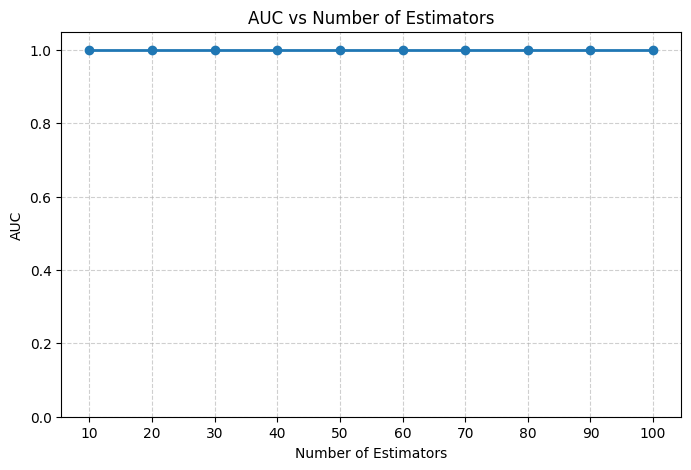

In [8]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

estimators = list(range(10, 101, 10))
auc_scores = []

for n_estimators in estimators:
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    rf.fit(x_train, y_train)
    rf_probabilities = rf.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, rf_probabilities)
    auc_scores.append(auc)
    print(f"Estimators: {n_estimators}, AUC: {auc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(estimators, auc_scores, marker='o', linewidth=2)
plt.title('AUC vs Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('AUC')
plt.xticks(estimators)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()